# Exercise 1: Profile Data

**Aim:** To work with vertical profile data and make some standard calculations.

**Required Outputs:**
Four figures should be generated (replace YourName with your actual last name):
- ex1fig1-SOMMERVILLE-Messfern.png: Showing the temperature and practical salinity
- ex1fig2-SOMMERVILLE-Messfern.png: Showing the conservative temperature and absolute salinity profiles
- ex1fig3-SOMMERVILLE-Messfern.png: Showing a basic TS profile
- ex1fig4-SOMMERVILLE-Messfern.png: Showing a TS profile focused on waters denser than 27.

**Fixed File Paths (DO NOT CHANGE):**
- NetCDF files: `./data/MSM121_054_1db.nc` and `./data/MSM121_054_1db_edited.nc`
- Figures directory: `./figures/`

---

**Complete your information here:**

- **Your Name:** [SOMMERVILLE]
- **Date:** [20.04.2026]
- **Student ID:** [7852758]


**Replace the placeholder text above with your actual information.**

## Importing Required Packages

In [1]:
import matplotlib.pyplot as plt
import gsw 
import numpy as np
import xarray as xr
import os

from matplotlib.ticker import ScalarFormatter

from seasenselib.readers import SbeCnvReader, NetCdfReader
from seasenselib.writers import NetCdfWriter

## File Paths Setup

In [3]:
cnv_file_with_path = '../data/MSM121_054_1db.cnv'

netcdf_file_with_path = '../data/MSM121_054_1db.nc'
netcdf_file_with_path_edited = '../data/MSM121_054_1db_edited.nc'
figdir = '../figures/'

In [4]:
if not os.path.exists(figdir):
    os.makedirs(figdir)
    
print(f"Figures will be saved to: {figdir}")
print(f"Data file: {cnv_file_with_path}")
print('Hello World')

Figures will be saved to: ../figures/
Data file: ../data/MSM121_054_1db.cnv
Hello World


In [5]:
assert 'figdir' in locals(), "figdir variable not defined"
assert figdir.endswith('/'), "figdir should end with '/'"
print("✓ File setup test passed!")

✓ File setup test passed!


## Transforming to xarray

### Convert CNV file to netCDF

In [6]:

import seasenselib as ssl
ctd_data = ssl.read(cnv_file_with_path)



INFO:pycnv: Opening file: ../data/MSM121_054_1db.cnv
INFO:pycnv:Dates computed based on timeS


Computing date


### Write to netCDF


In [8]:
from seasenselib.readers import SbeCnvReader, NetCdfReader
from seasenselib.writers import NetCdfWriter

In [11]:

ssl.write(ctd_data, netcdf_file_with_path)
print(f"NetCDF conversion complete: {netcdf_file_with_path}")

RuntimeError: Cannot write to file ../data/MSM121_054_1db.nc: [Errno 13] Permission denied: '/workspaces/messfern-1-ctd-HelenEire-1/data/MSM121_054_1db.nc'

In [10]:
assert os.path.exists(netcdf_file_with_path), "NetCDF file was not created"
print("✓ CNV to NetCDF conversion test passed!")

✓ CNV to NetCDF conversion test passed!


### Open file and show contents

In [76]:
print(netcdf_file_with_path)

../data/MSM121_054_1db.nc


In [18]:
xr.open_dataset(netcdf_file_with_path)

<xarray.Dataset> Size: 489kB
Dimensions:                (time: 3593)
Coordinates:
  * time                   (time) datetime64[ns] 29kB 2000-01-01T12:28:34.461...
    latitude               (time) float64 29kB ...
    longitude              (time) float64 29kB ...
Data variables: (12/14)
    conductivity_1         (time) float64 29kB ...
    conductivity_2         (time) float64 29kB ...
    flag                   (time) float64 29kB ...
    oxygen_1               (time) float64 29kB ...
    oxygen_2               (time) float64 29kB ...
    pressure               (time) float64 29kB ...
    ...                     ...
    temperature_2          (time) float64 29kB ...
    timeQ                  (time) float64 29kB ...
    timeS                  (time) float64 29kB ...
    depth                  (time) float64 29kB ...
    density                (time) float64 29kB ...
    potential_temperature  (time) float64 29kB ...
Attributes: (12/28)
    latitude:                   49.708333333333336
    longitude:                  -45.00066666666667
    CreateTime:                 2026-05-15T10:15:56
    DataType:                   TimeSeries
    cnv_sbe_model:              SBE 9
    cnv_software_version:       Seasave V 7.22
    ...                         ...
    processor_name:             seasenselib
    processor_version:          0.4.1
    processor_reader_class:     SbeCnvReader
    processor_python_version:   3.11.15
    processor_input_filename:   ../data/MSM121_054_1db.cnv
    processor_input_file_type:  SeaBird CNV

In [20]:
ctd_ds = xr.open_dataset(netcdf_file_with_path)
print(ctd_ds.info)

<bound method Dataset.info of <xarray.Dataset> Size: 489kB
Dimensions:                (time: 3593)
Coordinates:
  * time                   (time) datetime64[ns] 29kB 2000-01-01T12:28:34.461...
    latitude               (time) float64 29kB ...
    longitude              (time) float64 29kB ...
Data variables: (12/14)
    conductivity_1         (time) float64 29kB ...
    conductivity_2         (time) float64 29kB ...
    flag                   (time) float64 29kB ...
    oxygen_1               (time) float64 29kB ...
    oxygen_2               (time) float64 29kB ...
    pressure               (time) float64 29kB ...
    ...                     ...
    temperature_2          (time) float64 29kB ...
    timeQ                  (time) float64 29kB ...
    timeS                  (time) float64 29kB ...
    depth                  (time) float64 29kB ...
    density                (time) float64 29kB ...
    potential_temperature  (time) float64 29kB ...
Attributes: (12/28)
    latitude:    

In [77]:
# YOUR CODE HERE
# load data using xr.open_dataset()
# raise NotImplementedError()
ctd_ds = xr.open_dataset(netcdf_file_with_path)

# print data
print(ctd_ds.info)

<bound method Dataset.info of <xarray.Dataset> Size: 489kB
Dimensions:                (time: 3593)
Coordinates:
  * time                   (time) datetime64[ns] 29kB 2000-01-01T12:28:34.461...
    latitude               (time) float64 29kB ...
    longitude              (time) float64 29kB ...
Data variables: (12/14)
    conductivity_1         (time) float64 29kB ...
    conductivity_2         (time) float64 29kB ...
    flag                   (time) float64 29kB ...
    oxygen_1               (time) float64 29kB ...
    oxygen_2               (time) float64 29kB ...
    pressure               (time) float64 29kB ...
    ...                     ...
    temperature_2          (time) float64 29kB ...
    timeQ                  (time) float64 29kB ...
    timeS                  (time) float64 29kB ...
    depth                  (time) float64 29kB ...
    density                (time) float64 29kB ...
    potential_temperature  (time) float64 29kB ...
Attributes: (12/28)
    latitude:    

In [78]:
# Test that data loaded correctly
assert 'ctd_ds' in locals(), "ctd_ds variable not found"
assert hasattr(ctd_ds, 'data_vars'), "ctd_ds should be an xarray Dataset"
print("✓ Data loading test passed!")

✓ Data loading test passed!


In [21]:
assert 'ctd_ds' in locals(), "ctd_ds variable not found"
assert hasattr(ctd_ds, 'data_vars'), "ctd_ds should be an xarray Dataset"
print("✓ Data loading test passed!")

✓ Data loading test passed!


## Understanding the data format

The data stored within the netcdf file include measured parameters as `variables`, for example:

- `pressure` is pressure in decibars
- `temperature` is temperature in degrees Celcius
- `salinity` is salinity from the secondary sensor
- `latitude` is the position where the data were take from in degrees North (positive) or south (negative)
- `longitude` is the longitude with degrees east (positive) or west (negative)

The list of `Attributes` include details like the single value for latitude/longitude, or the date the file was created.

In [79]:
# Here we are defining the names of the variables in the netCDF file
# If your netcdf file calls salinity "PSAL", you would change the sal_string to 'PSAL'
sal_string = 'salinity'
temp_string = 'temperature'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
SA_string = 'absolute_salinity'
CT_string = 'conservative_temperature'
# You could also define these pairs in a dictionary (https://www.w3schools.com/python/python_dictionaries.asp)

In [22]:
temp_string = 'temperature_2'
sal_string = 'salinity'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
lon_string = 'longitude'
lat_string = 'latitude'
SA_string = 'absolute_salinity'
CT_string = 'conservative_temperature'


In [2]:
import matplotlib.pyplot as plt

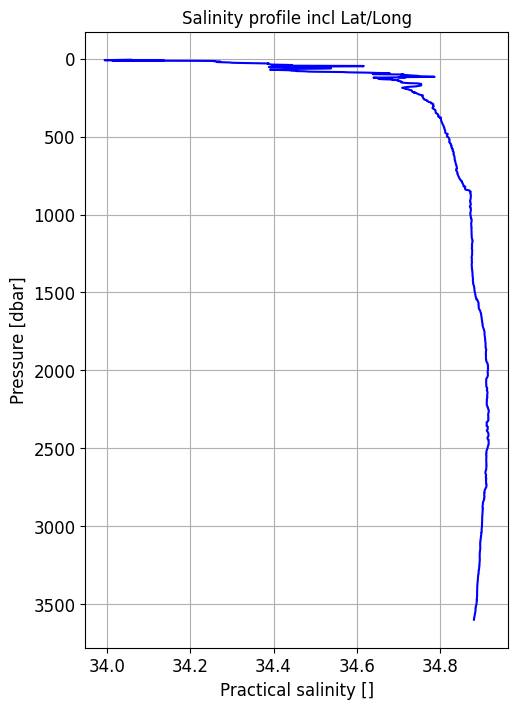

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(1,figsize=(12,8)) 
plt.subplot(1,2,1)
plt.plot(ctd_ds[sal_string], ctd_ds[pres_string], color='blue')
plt.ylabel('Pressure [dbar]', fontsize=12)
plt.xlabel('Practical salinity []', fontsize=12)
plt.title('Salinity profile incl Lat/Long', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()
plt.savefig(figdir + 'ex1fig1-SOMMERVILLE-Messfern.png')




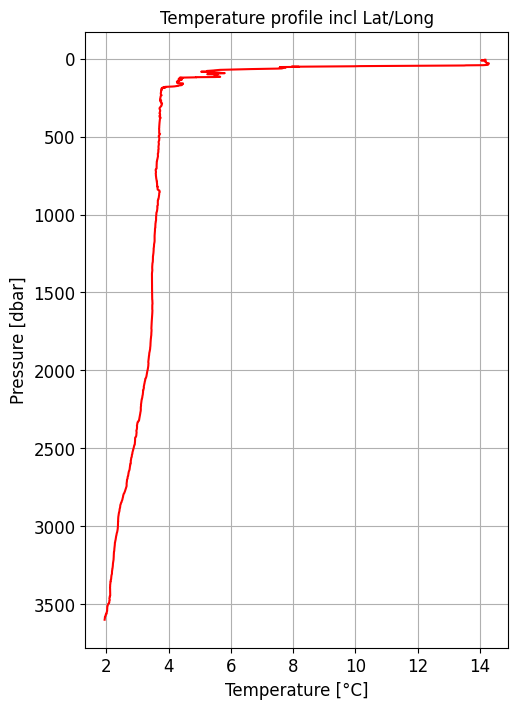

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(1,figsize=(12, 8)) 
plt.subplot(1,2,2)
plt.plot(ctd_ds[temp_string], ctd_ds[pres_string], color='red')
plt.ylabel('Pressure [dbar]', fontsize=12)
plt.xlabel('Temperature [°C]', fontsize=12)
plt.title('Temperature profile incl Lat/Long', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()
plt.savefig(figdir + 'ex1fig1-SOMMERVILLE-Messfern.png')


In [83]:
#Test that Figure 1 was created correctly
import glob
fig1_files = glob.glob(figdir + 'ex1fig1-*-Messfern.png')
assert len(fig1_files) > 0, "Figure 1 (ex1fig1-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig1_files:
    pass
print(f"✓ Figure 1 test passed: {fig1_files[0]}")

✓ Figure 1 test passed: ../figures/ex1fig1-SOMMERVILLE-Messfern.png


In [29]:
import glob
fig1_files = glob.glob(figdir + 'ex1fig1-*-Messfern.png')
assert len(fig1_files) > 0, "Figure 1 (ex1fig1-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig1_files:
    pass
print(f"✓ Figure 1 test passed: {fig1_files[0]}")

✓ Figure 1 test passed: ../figures/ex1fig1-SOMMERVILLE-Messfern.png


# Plot the temperature and salinity

To plot in Python, we often use the package `matplotlib` which you've imported above. This includes a variety of functions which can be used to generate figures in python.

In [84]:
# To initialise a figure, use matplotlib.plt.figure() which takes inputs within the brackets
# Since matplotlib is long to write, in the import cell above, we've imported it as plt
#plt.figure(1,figsize=(12, 8)) 

# In case the figure 1 already exists, clear it using clf()
plt.clf()

# Within the figure window, we'll actually have two separate sets of axes.  These are called 'subplots' in matplotlib
# We'll have two subplots, one next to the other, so we'll have a 1x2 grid of subplots
#plt.subplot(1,2,1)

# To plot salinity, we need to reference the salinity variable in the dataset.  This is done using the syntax ctd_ds['PSAL2']
# Here, ctd_ds is the name of the dataset, and 'PSAL2' is the name of the variable.  The variable name is case sensitive.
#plt.plot(ctd_ds[sal_string], ctd_ds[pres_string], color='blue')

# Now we'd like to annotate our figure.  We can do this using the plt.xlabel() and plt.ylabel() functions
# These functions take a string as an argument, which is the text that will be displayed on the x and y axes
# An optional second argument can be used to specify the fontsize.  IMPORTANT: choose values to make the text readable.
#plt.xlabel('Practical salinity' , fontsize=12)
#plt.ylabel('Pressure [dbar]', fontsize=12)

# Since pressure decreases with depth, we want to invert the y-axis so that the surface is at the top of the plot
#plt.gca().invert_yaxis()

# Here we specify where exactly the x-ticks should be placed.  We want them at 34, 34.5, and 35
#x_ticks = [34, 34.5, 35]
#plt.xticks(x_ticks, fontsize=12)

# We don't specify for the y-axis, but we do want the text size to be readable.
#plt.yticks(fontsize=12)

# Finally, we can add a title to the plot using plt.title().  This function also takes a string as an argument.
#plt.title('Salinity profile', fontsize=12)
#plt.grid(True)

# YOUR TURN: Now, let's plot the temperature profile on the right-hand side of the figure

#YOUR CODE HERE
# Now we'd like to annotate our figure.  We can do this using the plt.xlabel() and plt.ylabel() functions
# These functions take a string as an argument, which is the text that will be displayed on the x and y axes
# An optional second argument can be used to specify the fontsize.  IMPORTANT: choose values to make the text readable.
#plt.xlabel('Practical salinity' , fontsize=12)
#plt.ylabel('Pressure [dbar]', fontsize=12)

# Since pressure decreases with depth, we want to invert the y-axis so that the surface is at the top of the plot
#plt.gca().invert_yaxis()

# Here we specify where exactly the x-ticks should be placed.  We want them at 34, 34.5, and 35
#x_ticks = [34, 34.5, 35]
#plt.xticks(x_ticks, fontsize=12)

# We don't specify for the y-axis, but we do want the text size to be readable.
#plt.yticks(fontsize=12)

# Finally, we can add a title to the plot using plt.title().  This function also takes a string as an argument.
#plt.title('Salinity profile', fontsize=12)
#plt.grid(True)

# YOUR TURN: Now, let's plot the temperature profile on the right-hand side of the figure
# Complete the temperature plot following the same pattern as the salinity plot
# Plot temperature vs pressure, add labels, title, formatting
# Remember to invert the y-axis and add grid

# This code saves the figure to a file.  The file type is determined by the extension of the filename.
# IMPORTANT: Change YourName to your actual last name

# This code saves the figure to a file.  The file type is determined by the extension of the filename.
# IMPORTANT: Change YourName to your actual last name
#plt.savefig(figdir + 'ex1fig1-SOMMERVILLE-Messfern.png')
#plt.show()
#plt.savefig(figdir + 'ex1fig1-SOMMERVILLE-Messfern.png')

<Figure size 640x480 with 0 Axes>

In [85]:
# Test that Figure 1 was created correctly - Instructions
#import glob
#fig1_files = glob.glob(figdir + 'ex1fig1-*-Messfern.png')
#assert len(fig1_files) > 0, "Figure 1 (ex1fig1-YourName-Messfern.png) was not created"
#for fig_file in fig1_files:
   # assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
#print(f"✓ Figure 1 test passed: {fig1_files[0]}")

# Checklist for figure details to change:

- [ ] Change the shallow limit to be exactly zero
- [ ] Change the gridlines to be dashed (or dotted)
- [ ] Add additional ticks on the x-axis to show more detail
- [ ] Reduce the ticks and gridlines on the y-axis to be every 1000m
- [ ] Change the title to also include the latitude/longitude of the profile
- [ ] Add empty square brackets after Practical Salinity [ ] to indicate that there are no units
- [ ] Make the figure size about 1/3rd the height of A4 paper, and the text width to fit on A4 paper with margins.
- [ ] Change the font to Times New Roman or another serif font.

## Calculating TEOS-10 parameters

While data are collected as practical salinity and in situ temperature, in Messmethoden, we'll learn that we plot or represent the data by the quantities "Absolute salinity" and "conservative temperature". These are better tracers of the properties within the ocean.

To convert from practical to absolute salinity and temperature to conservative, we use the TEOS-10 toolbox, sometimes called the "Gibbs Seawater Toolbox". In Python, you've loaded this as `import gsw`.

https://teos-10.github.io/GSW-Python/conversions.html

In [86]:
# YOUR CODE HERE
# Calculate absolute salinity
# SA_2 = gsw.conversions.SA_from_SP(...)

# Calculate conservative temperature
# CT_2 = gsw.conversions.CT_from_t(...)

# Add the new variables to the dataset
# Note: Use .values to extract the data from the DataArray
# ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA_2.values)
# ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
# ctd_ds[SA_string].attrs['units'] = 'g/kg'

# Follow the same pattern for conservative temperature
#raise NotImplementedError()
# ctd_ds[CT_string] = (ctd_ds[temp_string].dims, CT_2.values)
# ctd_ds[CT_string].attrs['long_name'] = 'Conservative Temperature'
# ctd_ds[CT_string].attrs['units'] = 'degC'

# Check the data.  Note that the new variables are now in the dataset.
#print(ctd_ds.info)

In [30]:
import matplotlib.pyplot as plt
import gsw 
import numpy as np
import xarray as xr
import os

In [31]:
SA = gsw.SA_from_SP(SP=ctd_ds[sal_string],p=ctd_ds[pres_string],lon=ctd_ds.attrs['longitude'],lat=ctd_ds.attrs['latitude'])
ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA.values)
ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
ctd_ds[SA_string].attrs['units'] = 'g/kg'


In [32]:
CT_2 = gsw.conversions.CT_from_t(SA=SA,t=ctd_ds[temp_string],p=ctd_ds[pres_string])
ctd_ds[CT_string] = (ctd_ds[temp_string].dims, CT_2.values)
ctd_ds[CT_string].attrs['long_name'] = 'Conservative Temperature'
ctd_ds[CT_string].attrs['units'] = 'degC'

In [33]:
assert SA_string in ctd_ds.data_vars, f"Missing {SA_string} variable in dataset"
assert CT_string in ctd_ds.data_vars, f"Missing {CT_string} variable in dataset"
print("✓ TEOS-10 calculations test passed!")

✓ TEOS-10 calculations test passed!


In [34]:
# Test TEOS-10 calculations
assert SA_string in ctd_ds.data_vars, f"Missing {SA_string} variable in dataset"
assert CT_string in ctd_ds.data_vars, f"Missing {CT_string} variable in dataset"
print("✓ TEOS-10 calculations test passed!")

✓ TEOS-10 calculations test passed!


You can also calculate and add the field to the data structure in a single line

In [92]:
# Calculate depth (optional)
#ctd_ds['DEPTH'] = gsw.z_from_p(ctd_ds['PRES'], ctd_ds['LATITUDE']) # convert pressure to depth

## Plot absolute and conservative temperature profiles

In [93]:
# YOUR CODE HERE
# Plot the absolute salinity and conservative temperature profiles against depth in meters.
# Create a similar two-panel figure to Figure 1, but using the TEOS-10 variables
# Left panel: Absolute salinity vs pressure
# Right panel: Conservative temperature vs pressure
#raise NotImplementedError()

# IMPORTANT: Change YourName to your actual last name
plt.savefig(figdir + 'ex1fig2-SOMMERVILLE-Messfern.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
import gsw 
import numpy as np
import xarray as xr
import os

In [36]:
import xarray as xr
netcdf_file_with_path = '../data/MSM121_054_1db.nc'  
ctd_ds = xr.open_dataset(netcdf_file_with_path)

In [37]:
print(ctd_ds.info)

<bound method Dataset.info of <xarray.Dataset> Size: 489kB
Dimensions:                (time: 3593)
Coordinates:
  * time                   (time) datetime64[ns] 29kB 2000-01-01T12:28:34.461...
    latitude               (time) float64 29kB ...
    longitude              (time) float64 29kB ...
Data variables: (12/14)
    conductivity_1         (time) float64 29kB ...
    conductivity_2         (time) float64 29kB ...
    flag                   (time) float64 29kB ...
    oxygen_1               (time) float64 29kB ...
    oxygen_2               (time) float64 29kB ...
    pressure               (time) float64 29kB ...
    ...                     ...
    temperature_2          (time) float64 29kB ...
    timeQ                  (time) float64 29kB ...
    timeS                  (time) float64 29kB ...
    depth                  (time) float64 29kB ...
    density                (time) float64 29kB ...
    potential_temperature  (time) float64 29kB ...
Attributes: (12/28)
    latitude:    

In [38]:
SA = gsw.SA_from_SP(SP=ctd_ds[sal_string],p=ctd_ds[pres_string],lon=ctd_ds.attrs['longitude'],lat=ctd_ds.attrs['latitude'])

In [39]:
sal_string = 'salinity'
temp_string = 'temperature_2'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
SA_string = 'absolute_salinity'

SA = gsw.SA_from_SP(ctd_ds[sal_string], ctd_ds[pres_string], ctd_ds[lon_string], ctd_ds[lat_string])

ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA.values)
ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
ctd_ds[SA_string].attrs['units'] = 'g/kg'

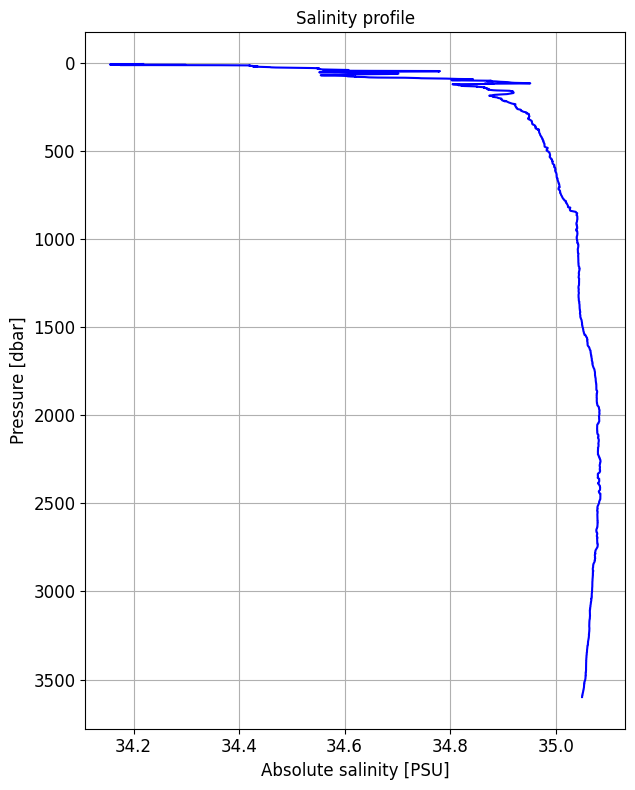

<Figure size 640x480 with 0 Axes>

In [40]:
plt.figure(2,figsize=(12, 8)) 
plt.subplot(1,2,1)
plt.plot(ctd_ds[SA_string], ctd_ds[pres_string], color='blue')
plt.ylabel('Pressure [dbar]', fontsize=12)
plt.xlabel('Absolute salinity [PSU]', fontsize=12)
plt.title('Salinity profile', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.savefig(figdir + 'ex1fig2-SOMMERVILLE-Messfern.png')



In [41]:
sal_string = 'salinity'
temp_string = 'temperature_2'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
CT_string = 'conservative_temperature'

In [42]:
CT_2 = gsw.conversions.CT_from_t(SA=SA,t=ctd_ds[temp_string],p=ctd_ds[pres_string])
ctd_ds[CT_string] = (ctd_ds[temp_string].dims, CT_2.values)
ctd_ds[CT_string].attrs['long_name'] = 'Conservative Temperature'
ctd_ds[CT_string].attrs['units'] = 'degC'

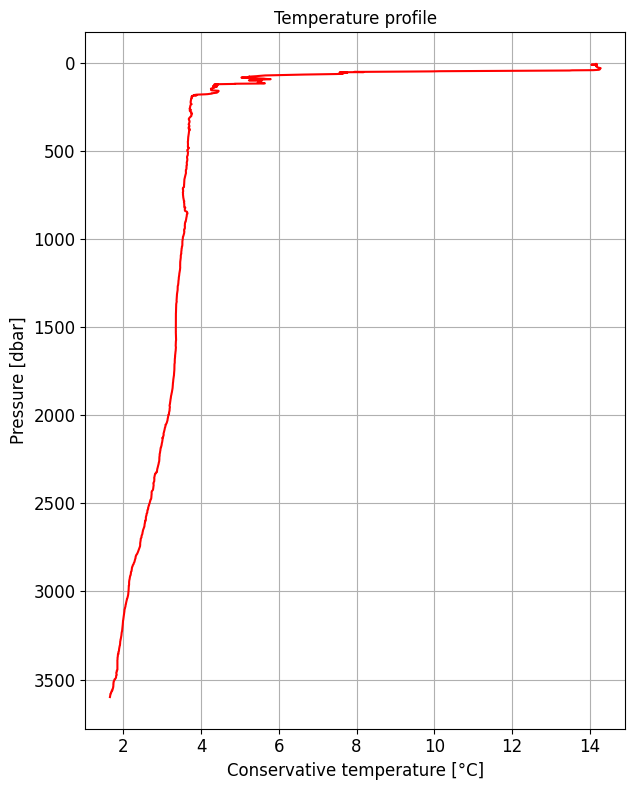

<Figure size 640x480 with 0 Axes>

In [43]:
plt.figure(2,figsize=(12, 8)) 
plt.subplot(1,2,2)
plt.plot(ctd_ds[CT_string], ctd_ds[pres_string], color='red')
plt.ylabel('Pressure [dbar]', fontsize=12)
plt.xlabel('Conservative temperature [°C]', fontsize=12)
plt.title('Temperature profile', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.savefig(figdir + 'ex1fig2-SOMMERVILLE-Messfern.png')



In [103]:
#Test that Figure 2 was created correctly
import glob
fig2_files = glob.glob(figdir + 'ex1fig2-*-Messfern.png')
assert len(fig2_files) > 0, "Figure 2 (ex1fig2-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig2_files:
   pass
print(f"✓ Figure 2 test passed: {fig2_files[0]}")

✓ Figure 2 test passed: ../figures/ex1fig2-SOMMERVILLE-Messfern.png


In [44]:
import glob
fig2_files = glob.glob(figdir + 'ex1fig2-*-Messfern.png')
assert len(fig2_files) > 0, "Figure 2 (ex1fig2-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig2_files:
   pass
print(f"✓ Figure 2 test passed: {fig2_files[0]}")

✓ Figure 2 test passed: ../figures/ex1fig2-SOMMERVILLE-Messfern.png


### Saving xarray to netCDF file

Since we've manipulated the data, and may want to use the new variables "Absolute salinity" and "Conservative temperature" again later, let's save the new data file.

In [45]:
ctd_ds.to_netcdf(netcdf_file_with_path_edited)

## T-S Diagram

A T-S diagram has salinity on the x-axis and temperature on the y-axis, and contours of density (sigma_0) added.

In [105]:
# YOUR CODE HERE
# Follow the original template pattern to create T-S diagram
# Reference: https://stackoverflow.com/questions/41634179/matplotlib-contour-lines-are-not-closing-up

# On a TS diagram, the X axis is salinity and the Y axis is temperature.  
# As a helpful reminder, we can create variables X and Y.
#x = ctd_ds[SA_string]
#y = ctd_ds[CT_string]

# A typical TS diagram also has contours of potential density using gsw package.
# Use np.meshgrid and gsw.density.sigma0() to create density contours
# Create a grid for salinity and temperature
#S_min, S_max = x.min().values, x.max().values
#T_min, T_max = y.min().values, y.max().values
#S_range = np.linspace(S_min - 0.1, S_max + 0.1, 100)
#T_range = np.linspace(T_min - 0.1, T_max + 0.1, 100)
#S_mesh, T_mesh = np.meshgrid(S_range, T_range)

# Compute potential density anomaly (sigma0)
#sigma0 = gsw.density.sigma0(S_mesh, T_mesh)

# Plot the contours
#plt.contour(S_mesh, T_mesh, sigma0, levels=np.arange(20, 30, 0.5), colors='black', linewidths=0.5)

# Plot the data points and add contour lines with labels
#plt.plot(x, y, 'o-', color='red', linewidth=2, markersize=4)

# Add contour labels
#CS = plt.contour(S_mesh, T_mesh, sigma0, levels=np.arange(20, 30, 0.5), colors='black', linewidths=0.5)
#plt.clabel(CS, inline=True, fontsize=8, fmt='%.1f')

# Set labels and title
#plt.xlabel('Absolute Salinity (g/kg)', fontsize=12)
#plt.ylabel('Conservative Temperature (°C)', fontsize=12)
#plt.title('T-S Diagram with Density Contours', fontsize=14)
#plt.grid(True, alpha=0.3)

# IMPORTANT: Change YourName to your actual last name
#plt.savefig(figdir + 'ex1fig3-SOMMERVILLE-Messfern.png')
#plt.show()

In [46]:
import matplotlib.pyplot as plt
import gsw 
import numpy as np
import xarray as xr
import os
from matplotlib.ticker import ScalarFormatter




In [47]:
import xarray as xr
netcdf_file_with_path = '../data/MSM121_054_1db.nc'  
ctd_ds = xr.open_dataset(netcdf_file_with_path)

In [48]:
print(ctd_ds.info)

<bound method Dataset.info of <xarray.Dataset> Size: 489kB
Dimensions:                (time: 3593)
Coordinates:
  * time                   (time) datetime64[ns] 29kB 2000-01-01T12:28:34.461...
    latitude               (time) float64 29kB ...
    longitude              (time) float64 29kB ...
Data variables: (12/14)
    conductivity_1         (time) float64 29kB ...
    conductivity_2         (time) float64 29kB ...
    flag                   (time) float64 29kB ...
    oxygen_1               (time) float64 29kB ...
    oxygen_2               (time) float64 29kB ...
    pressure               (time) float64 29kB ...
    ...                     ...
    temperature_2          (time) float64 29kB ...
    timeQ                  (time) float64 29kB ...
    timeS                  (time) float64 29kB ...
    depth                  (time) float64 29kB ...
    density                (time) float64 29kB ...
    potential_temperature  (time) float64 29kB ...
Attributes: (12/28)
    latitude:    

In [49]:
sal_string = 'salinity'
temp_string = 'temperature_2'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
SA_string = 'absolute_salinity'
CT_string = 'conservative_temperature'



In [50]:
SA = gsw.SA_from_SP(SP=ctd_ds[sal_string],p=ctd_ds[pres_string],lon=ctd_ds.attrs['longitude'],lat=ctd_ds.attrs['latitude'])
ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA.values)
ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
ctd_ds[SA_string].attrs['units'] = 'g/kg'


In [51]:
CT = gsw.conversions.CT_from_t(SA=SA,t=ctd_ds[temp_string],p=ctd_ds[pres_string])
ctd_ds[CT_string] = (ctd_ds[temp_string].dims, CT.values)
ctd_ds[CT_string].attrs['long_name'] = 'Conservative Temperature'
ctd_ds[CT_string].attrs['units'] = '°C'
CT=ctd_ds[CT_string]

In [52]:
x = ctd_ds[SA_string]
y = ctd_ds[CT_string]

In [53]:
S_min, S_max = x.min().values, x.max().values
T_min, T_max = y.min().values, y.max().values
S_range = np.linspace(S_min - 0.1, S_max + 0.1, 100)
T_range = np.linspace(T_min - 0.1, T_max + 0.1, 100)
S_mesh, T_mesh = np.meshgrid(S_range, T_range)
sigma0 = gsw.density.sigma0(S_mesh, T_mesh)


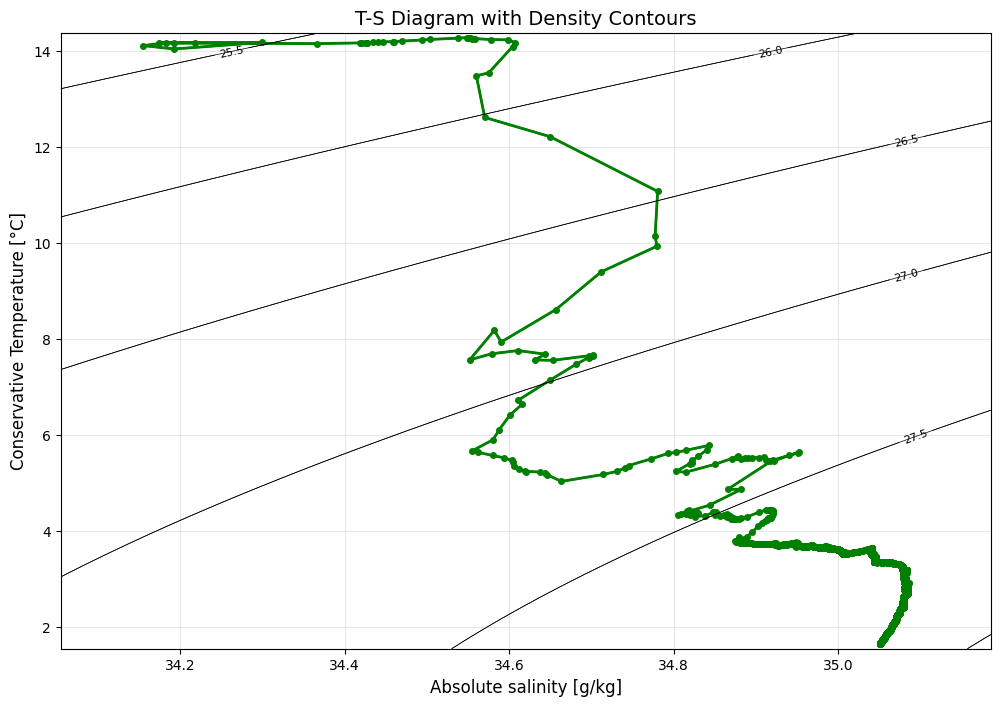

<Figure size 640x480 with 0 Axes>

In [54]:
plt.figure(3,figsize=(12, 8)) 
plt.subplot(1,1,1)
plt.plot(ctd_ds[SA_string], ctd_ds[CT_string], color='green')
plt.plot(x, y, 'o-', color='green', linewidth=2, markersize=4)
plt.xlabel('Absolute salinity [g/kg]', fontsize=12)
plt.ylabel('Conservative Temperature [°C]', fontsize=12)
CS = plt.contour(S_mesh, T_mesh, sigma0, levels=np.arange(20, 30, 0.5), colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=8, fmt='%.1f')
plt.title('T-S Diagram with Density Contours', fontsize=14)
plt.grid(True, alpha=0.3)
plt.contour(S_mesh, T_mesh, sigma0, levels=np.arange(20, 30, 0.5), colors='black', linewidths=0.5)
plt.show()
plt.savefig(figdir + 'ex1fig3-SOMMERVILLE-Messfern.png')

In [55]:
import glob
fig3_files = glob.glob(figdir + 'ex1fig3-*-Messfern.png')
assert len(fig3_files) > 0, "Figure 3 (ex1fig3-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig3_files:
   pass
print(f"✓ Figure 3 test passed: {fig3_files[0]}")

✓ Figure 3 test passed: ../figures/ex1fig3-HelenEire-Messfern.png


In [62]:
import glob
fig3_files = glob.glob(figdir + 'ex1fig3-*-Messfern.png')
assert len(fig3_files) > 0, "Figure 3 (ex1fig3-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig3_files:
   pass
print(f"✓ Figure 3 test passed: {fig3_files[0]}")

✓ Figure 3 test passed: ../figures/ex1fig3-HelenEire-Messfern.png


In [115]:
#Test that Figure 3 was created correctly
import glob
fig3_files = glob.glob(figdir + 'ex1fig3-*-Messfern.png')
assert len(fig3_files) > 0, "Figure 3 (ex1fig3-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig3_files:
   pass
print(f"✓ Figure 3 test passed: {fig3_files[0]}")

✓ Figure 3 test passed: ../figures/ex1fig3-HelenEire-Messfern.png


## Enhanced T-S Diagram (Figure 4)

Repeat the plot here, but with the following enhancements:
- Plot the contours first, then the data points (makes data points more visible)
- Try removing the grid lines
- Change the aspect ratio of the plot to make it square
- Change the color of the line to red
- Change the axes limits to focus on the data denser than 27.00 kg/m³

In [116]:
# YOUR CODE HERE - instructions
# Repeat the T-S plot from Figure 3, but with these modifications:
# - Plot the contours first, then the data points (makes data points more visible)
# - Remove grid lines
# - Change the aspect ratio of the plot to make it square
# - Change the color of the line to red
# - Change the axes limits to focus on data denser than 27.00 kg/m^3
#raise NotImplementedError()

# Save the figure as a .png file in the figures directory
# IMPORTANT: Change YourName to your actual last name
#plt.savefig(figdir + 'ex1fig4-SOMMERVILLE-Messfern.png')
#plt.show()

In [56]:
sal_string = 'salinity'
temp_string = 'temperature_2'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
SA_string = 'absolute_salinity'
CT_string = 'conservative_temperature'

In [57]:
SA = gsw.SA_from_SP(SP=ctd_ds[sal_string],p=ctd_ds[pres_string],lon=ctd_ds.attrs['longitude'],lat=ctd_ds.attrs['latitude'])
ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA.values)
ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
ctd_ds[SA_string].attrs['units'] = 'g/kg'
CT = gsw.conversions.CT_from_t(SA=SA,t=ctd_ds[temp_string],p=ctd_ds[pres_string])
ctd_ds[CT_string] = (ctd_ds[temp_string].dims, CT.values)
ctd_ds[CT_string].attrs['long_name'] = 'Conservative Temperature'
ctd_ds[CT_string].attrs['units'] = '°C'

In [58]:
x= ctd_ds[SA_string]
y= ctd_ds[CT_string]

In [59]:
S_min, S_max = x.min().values, x.max().values
T_min, T_max = y.min().values, y.max().values
S_range = np.linspace(S_min - 0.1, S_max + 0.1, 100)
T_range = np.linspace(T_min - 0.1, T_max + 0.1, 100)
S_mesh, T_mesh = np.meshgrid(S_range, T_range)
sigma0 = gsw.density.sigma0(S_mesh, T_mesh)

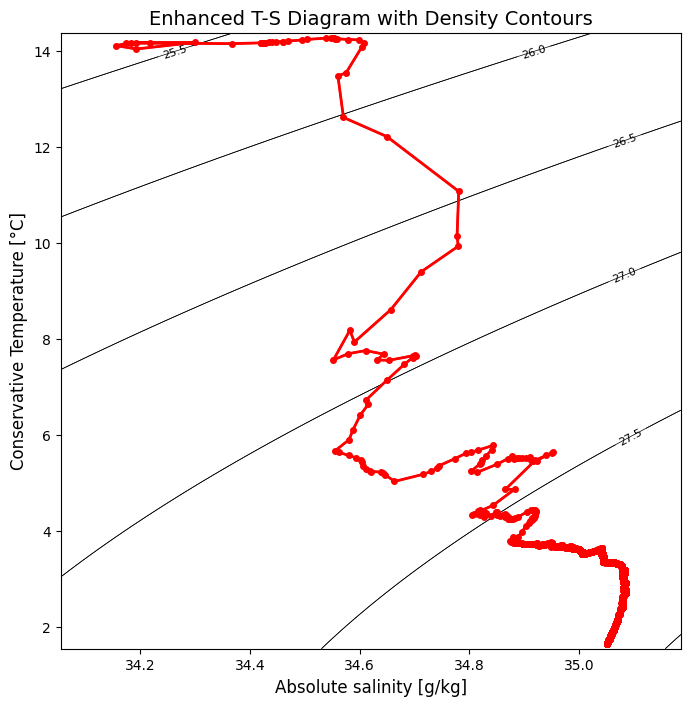

<Figure size 640x480 with 0 Axes>

In [60]:
plt.figure(4,figsize=(8, 8)) 
plt.subplot(1,1,1)
plt.plot(ctd_ds[SA_string], ctd_ds[CT_string], color='red')
CS = plt.contour(S_mesh, T_mesh, sigma0, levels=np.arange(20, 30, 0.5), colors='black', linewidths=0.5)
plt.contour(S_mesh, T_mesh, sigma0, levels=np.arange(20, 30, 0.5), colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=8, fmt='%.1f')
plt.plot(x, y, 'o-', color='red', linewidth=2, markersize=4)
plt.xlabel('Absolute salinity [g/kg]', fontsize=12)
plt.ylabel('Conservative Temperature [°C]', fontsize=12)
plt.title('Enhanced T-S Diagram with Density Contours', fontsize=14)
plt.show()
plt.savefig(figdir + 'ex1fig4-SOMMERVILLE-Messfern.png')

In [61]:
import glob
fig4_files = glob.glob(figdir + 'ex1fig4-*-Messfern.png')
assert len(fig4_files) > 0, "Figure 4 (ex1fig4-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig4_files:
   pass
print(f"✓ Figure 4 test passed: {fig4_files[0]}")

✓ Figure 4 test passed: ../figures/ex1fig4-SOMMERVILLE-Messfern.png


In [123]:
# Test that Figure 4 was created correctly
fig4_files = glob.glob(figdir + 'ex1fig4-*-Messfern.png')
assert len(fig4_files) > 0, "Figure 4 (ex1fig4-SOMMERVILLE-Messfern.png) was not created"
for fig_file in fig4_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 4 test passed: {fig4_files[0]}")

✓ Figure 4 test passed: ../figures/ex1fig4-SOMMERVILLE-Messfern.png


## Analysis Questions

**Note:** These questions are for your reflection and will be discussed in class after the assignment deadline. You do not need to submit written answers - they are not part of the automated grading.

**Question 1:** Compare the practical salinity vs. absolute salinity profiles (Figures 1 and 2). What differences do you observe and why are these important for oceanographic analysis?

**Question 2:** Examine your T-S diagrams (Figures 3 and 4). What do the density contours tell you about the water masses in this profile? Which parts of the water column are most/least dense?

**Question 3:** Based on the location of this CTD cast (North Atlantic, 49°42.5'N, 45°00.0'W) and the T-S characteristics you observe, what can you infer about the water masses present? Consider both surface and deep water properties.

**Optional Notes for Class Discussion:**
Feel free to jot down thoughts here, but this section is not graded:

1. [Your observations for Question 1]

2. [Your observations for Question 2]

3. [Your observations for Question 3]

## Conclusion

Congratulations! You have successfully completed this comprehensive oceanographic data analysis exercise. You have:

- Converted Sea-Bird CNV data to netCDF format using seasenselib
- Calculated TEOS-10 oceanographic parameters (Absolute Salinity, Conservative Temperature)
- Created professional oceanographic profile plots (Figures 1 & 2)
- Generated Temperature-Salinity diagrams with density contours (Figures 3 & 4)
- Analyzed real research data from the North Atlantic Ocean

This exercise demonstrates the complete workflow used by oceanographers for analyzing CTD data, from raw sensor data to scientific interpretation.

## Grading

**This assignment uses a tiered PASS system:**

✅ **PASS (Basic Requirements):**
- All required files created (NetCDF files, 4 figures)
- All automated tests pass (data valid, figures contain content)
- Personal information completed
- Code executes without errors

🌟 **PASS PLUS (Professional Quality):**
All PASS requirements PLUS:
- Sensible legends and titles on all figures
- Good choices for figure plotting (appropriate aspect ratios, professional color scales, clear line styles)
- All axes have proper labels with units (e.g., "Temperature (°C)", "Pressure (dbar)", "Salinity (g/kg)")
- Thoughtful formatting (readable fonts, appropriate figure sizes)
- Professional T-S diagram styling with proper density contour labels

❌ **FAIL Conditions:**
- Missing required outputs
- Test failures (invalid data, empty figures)
- Code execution errors
- Template placeholders not replaced

**Analysis Questions:** The analysis questions above are for reflection and will be discussed in class after the assignment deadline.